<a href="https://colab.research.google.com/github/frankodzia/ai-course-gp/blob/main/Lekcja_36_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

GRA MIGACZ

Część I.

1. Import bibliotek

In [4]:
# standardowe biblioteki
import os, sys, time, glob, random, base64, shutil, pathlib, io, json
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

# Colab wyświetlanie
from IPython.display import Javascript, HTML, display, Audio, Image as DImage
from google.colab.output import eval_js
from google.colab import output as colab_output

# TensorFlow/Keras
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mnv2_preprocess
from tensorflow.keras.models import load_model
print("TF:", tf.__version__)


TF: 2.20.0


2. Konfiguracja środowiska [ZMIENIAMY NA WŁASNE KATEOGRIE]

In [5]:
# Konfiguracja folderów projektu
BASE_DIR = "/content/projekt_knp"
RAW_DIR  = BASE_DIR + "/raw"      # tu robimy zdjęcia z kamerki
DATA_DIR = BASE_DIR + "/data"     # tu powstanie train/test do uczenia

# Kategorie
KATEGORIE = ["G", "I", "G", "A"]

IMG_SIZE   = (224, 224)
TRAIN_RATIO = 0.8  # 80% train, 20% test

# Tworzymy katalogi na surowe zdjęcia
for k in KATEGORIE:
    os.makedirs(os.path.join(RAW_DIR, k), exist_ok=True)

print("Kategorie:", KATEGORIE)
print("RAW_DIR:", RAW_DIR)


Kategorie: ['G', 'I', 'G', 'A']
RAW_DIR: /content/projekt_knp/raw


3. Funkcja zbierania danych (wykorzystanie Javascript)

In [6]:


def zbierz_proby(kategoria, ile_min=20, jakosc=0.9, lustrzane=True):

    target = os.path.join(RAW_DIR, kategoria)
    os.makedirs(target, exist_ok=True)

    js = Javascript('''
      async function sesja(nMin, q) {
        const div = document.createElement('div');
        const btn = document.createElement('button');
        btn.textContent = 'Zrób zdjęcie';
        btn.style.fontSize = '16px';
        btn.style.marginRight = '8px';
        const done = document.createElement('button');
        done.textContent = 'Zakończ';
        done.disabled = true;
        const info = document.createElement('span');
        info.style.marginLeft = '10px';
        info.textContent = '0 / ' + nMin;

        div.appendChild(btn);
        div.appendChild(done);
        div.appendChild(info);

        const video = document.createElement('video');
        video.style.display = 'block';
        video.style.maxWidth = '480px';
        const stream = await navigator.mediaDevices.getUserMedia({video:true});
        document.body.appendChild(div);
        div.appendChild(video);
        video.srcObject = stream;
        await video.play();
        google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

        const images = [];
        btn.onclick = () => {
          const canvas = document.createElement('canvas');
          canvas.width = video.videoWidth;
          canvas.height = video.videoHeight;
          canvas.getContext('2d').drawImage(video, 0, 0);
          images.push(canvas.toDataURL('image/jpeg', q));
          info.textContent = images.length + ' / ' + nMin;
          if (images.length >= nMin) done.disabled = false;
        };

        await new Promise(resolve => done.onclick = resolve);
        stream.getTracks().forEach(t => t.stop());
        div.remove();
        return images;
      }
    ''')
    display(js)
    data_urls = eval_js(f"sesja({ile_min}, {jakosc})")


    zapisane = 0
    for i, d in enumerate(data_urls):
        raw = base64.b64decode(d.split(',')[1])
        fname = os.path.join(target, f"{kategoria}_{int(time.time()*1000)}_{i:03d}.jpg")
        with open(fname, 'wb') as f:
            f.write(raw)
        zapisane += 1

        if lustrzane:
            img = Image.open(io.BytesIO(raw)).convert('RGB')
            img = ImageOps.mirror(img)
            fname2 = os.path.join(target, f"{kategoria}_{int(time.time()*1000)}_{i:03d}_m.jpg")
            img.save(fname2, "JPEG", quality=int(jakosc*100))
            zapisane += 1

    print("Zapisano:", zapisane, "plików do", target)




4. Zbieranie danych do modelu [ROBIMY NA ZAJĘCIACH]

In [7]:
zbierz_proby("G", ile_min = 50)

<IPython.core.display.Javascript object>

MessageError: NotFoundError: Requested device not found

In [ ]:
zbierz_proby("A", ile_min = 50)

In [ ]:
zbierz_proby("I", ile_min = 50)

5. Podział danych

In [8]:
# Podział na train/test - kopiowanie obrazów do konkretnych folderów

def podziel_train_test():
    if os.path.exists(DATA_DIR):
        shutil.rmtree(DATA_DIR)
    for split in ["train", "test"]:
        for k in KATEGORIE:
            os.makedirs(os.path.join(DATA_DIR, split, k), exist_ok=True)

    for k in KATEGORIE:
        pliki = glob.glob(os.path.join(RAW_DIR, k, "*"))
        pliki = [p for p in pliki if os.path.isfile(p)]
        random.shuffle(pliki)
        n = len(pliki)
        n_train = int(n * TRAIN_RATIO)
        train_files = pliki[:n_train]
        test_files  = pliki[n_train:]
        for src in train_files:
            shutil.copy2(src, os.path.join(DATA_DIR, "train", k, os.path.basename(src)))
        for src in test_files:
            shutil.copy2(src, os.path.join(DATA_DIR, "test", k, os.path.basename(src)))
    print("Dane w", DATA_DIR)




In [9]:
podziel_train_test()

Dane w /content/projekt_knp/data


6. Wczytanie danych i trening modelu

In [10]:
# Funkcje wczytania danych i budowy modelu
AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 32

def wczytaj_dane():
    train_ds = image_dataset_from_directory(
        os.path.join(DATA_DIR, "train"),
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode='categorical',
        shuffle=True
    )
    test_ds = image_dataset_from_directory(
        os.path.join(DATA_DIR, "test"),
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode='categorical',
        shuffle=False
    )
    return train_ds.prefetch(AUTOTUNE), test_ds.prefetch(AUTOTUNE), train_ds.class_names

def zbuduj_model(n_klas):

  #odporność modelu
    wej = layers.Input(shape=IMG_SIZE + (3,))
    x = layers.RandomFlip("horizontal")(wej)
    x = layers.RandomRotation(0.05)(x)
    x = layers.RandomZoom(0.1)(x)
    x = mnv2_preprocess(x)

    baza = MobileNetV2(include_top=False, input_tensor=x, weights="imagenet", pooling="avg")
    baza.trainable = False

    x = layers.Dropout(0.2)(baza.output)
    wyj = layers.Dense(n_klas, activation="softmax")(x)

    model = models.Model(wej, wyj)
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model




Found 507 files belonging to 3 classes.
Found 147 files belonging to 3 classes.
class_names: ['A', 'G', 'I']


/tmp/ipykernel_2784/1165117739.py:31: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  baza = MobileNetV2(include_top=False, input_tensor=x, weights="imagenet", pooling="avg")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 14s 281ms/step - accuracy: 0.8087 - loss: 0.5213 - val_accuracy: 1.0000 - val_loss: 0.0819
Epoch 2/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 1.0000 - loss: 0.0457 - val_accuracy: 1.0000 - val_loss: 0.0171
Epoch 3/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - accuracy: 1.0000 - loss: 0.0159 - val_accuracy: 1.0000 - val_loss: 0.0083
Epoch 4/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 1.0000 - loss: 0.0103 - val_accuracy: 1.0000 - val_loss: 0.0066
Epoch 5/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 1.0000 - loss: 0.0090 - val_accuracy: 1.0000 - val_loss: 0.0051
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 1.0000 - loss: 0.0051
Test acc: 1.0


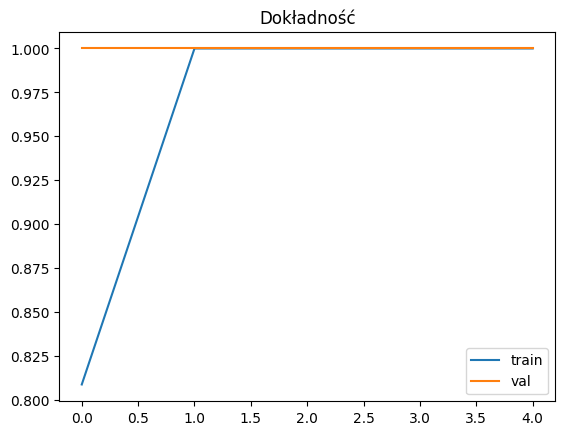

In [11]:
# Trenujemy model
train_ds, test_ds, class_names = wczytaj_dane()
print("class_names:", class_names)

model = zbuduj_model(len(class_names))
hist = model.fit(train_ds, validation_data=test_ds, epochs=5)
loss, acc = model.evaluate(test_ds)
print("Test acc:", acc)

plt.plot(hist.history['accuracy'], label='train')
plt.plot(hist.history['val_accuracy'], label='val')
plt.legend(); plt.title("Dokładność"); plt.show()




7. Predykcja LIVE z kamerki

Funkcja kamerki

In [16]:
# Predykcja z kamerki


def take_photo(nazwa="foto.jpg", jakosc=0.9):
    js = Javascript('''
      async function f(q) {
        const div = document.createElement('div');
        const b = document.createElement('button');
        b.textContent = 'Zrób zdjęcie';
        b.style.fontSize = '16px';
        b.style.marginBottom = '8px';
        div.appendChild(b);

        const video = document.createElement('video');
        video.style.display='block';
        video.style.maxWidth='480px';
        const stream = await navigator.mediaDevices.getUserMedia({video:true});
        document.body.appendChild(div);
        div.appendChild(video);
        video.srcObject = stream;
        await video.play();
        google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

        await new Promise(resolve => b.onclick = resolve);
        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;
        canvas.getContext('2d').drawImage(video, 0, 0);
        stream.getTracks().forEach(t => t.stop());
        div.remove();
        return canvas.toDataURL('image/jpeg', q);
      }
    ''')
    display(js)
    data = eval_js(f"f({jakosc})")
    raw = base64.b64decode(data.split(',')[1])
    with open(nazwa, 'wb') as f:
        f.write(raw)
    return nazwa

def przygotowanie(path, rozmiar=IMG_SIZE, mirror=False):
    img = Image.open(path).convert("RGB")
    w, h = img.size
    m = min(w, h)
    img = img.crop(((w-m)//2, (h-m)//2, (w+m)//2, (h+m)//2)).resize(rozmiar)
    if mirror:
        img = ImageOps.mirror(img)
    x = np.asarray(img).astype("float32")
    x = np.expand_dims(x, 0)  # (1,H,W,3) – preprocess jest w MODEL-U
    return x






Funkcja kamerka + klasyfikacja

In [19]:
# Funkcja TOP3
def przewidz(path, mirror=False, topk=3):
    x = przygotowanie(path, mirror=mirror)
    p = model.predict(x, verbose=0)[0]
    idx = int(np.argmax(p))
    etyk = class_names[idx]              # surowa etykieta (nazwa folderu)
    tytul = etyk.replace("_"," ").title()
    pew = float(p[idx])

    print(f"Przewidziano: {tytul} ({etyk}), pewność: {pew:.2f}")
    top = np.argsort(p)[-topk:][::-1]
    print("Top-3:")
    for i in top:
        print(f"  {class_names[i]}: {p[i]:.3f}")

In [20]:
foto = take_photo("foto.jpg")
przewidz(foto, mirror=False)

<IPython.core.display.Javascript object>

MessageError: NotFoundError: Requested device not found

In [22]:
from google.colab import files

uploaded = files.upload()

for nazwa in uploaded.keys():
  przewidz(nazwa)

Saving frame_00_02_0128.png to frame_00_02_0128.png
Przewidziano: I (I), pewność: 0.75
Top-3:
  I: 0.748
  A: 0.151
  G: 0.101


Część II.

1. Automatyczne zdjęcie w 3s

In [ ]:
# ODLICZANIE 3 SEKUND + AUTOMATYCZNE ZDJĘCIE


def take_photo_countdown_3s(nazwa="foto_3s.jpg", jakosc=0.9):
    js = Javascript('''
      async function snap3s(q){
        const wrap = document.createElement('div');
        const video = document.createElement('video');
        const btn = document.createElement('button');
        const overlay = document.createElement('div');

        btn.textContent = 'Start';
        btn.style.fontSize = '16px';
        btn.style.margin = '8px 0';

        video.style.display = 'block';
        video.style.maxWidth = '480px';
        video.style.borderRadius = '8px';

        overlay.style.position = 'fixed';
        overlay.style.left = 0;
        overlay.style.top = 0;
        overlay.style.right = 0;
        overlay.style.bottom = 0;
        overlay.style.display = 'flex';
        overlay.style.alignItems = 'center';
        overlay.style.justifyContent = 'center';
        overlay.style.fontFamily = 'sans-serif';
        overlay.style.fontSize = '120px';
        overlay.style.fontWeight = '700';
        overlay.style.color = 'white';
        overlay.style.background = 'rgba(0,0,0,0.35)';
        overlay.style.zIndex = 999999;
        overlay.style.visibility = 'hidden';

        document.body.appendChild(wrap);
        wrap.appendChild(video);
        wrap.appendChild(btn);
        document.body.appendChild(overlay);

        const stream = await navigator.mediaDevices.getUserMedia({video:true});
        video.srcObject = stream;
        await video.play();
        google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

        await new Promise(r => btn.onclick = r);

        overlay.style.visibility = 'visible';
        for (let s = 3; s >= 1; s--) {
          overlay.textContent = String(s);
          await new Promise(r => setTimeout(r, 1000));
        }
        overlay.textContent = 'GO!';
        await new Promise(r => setTimeout(r, 250));

        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;
        canvas.getContext('2d').drawImage(video, 0, 0);

        stream.getTracks().forEach(t => t.stop());
        wrap.remove();
        overlay.remove();

        return canvas.toDataURL('image/jpeg', q);
      }
    ''')
    display(js)
    data = eval_js(f'snap3s({jakosc})')
    raw = base64.b64decode(data.split(',')[1])
    with open(nazwa, 'wb') as f:
        f.write(raw)
    return nazwa

In [ ]:
foto3s = take_photo_countdown_3s("test_3s.jpg", jakosc=0.9)
przewidz(foto3s, mirror=False)

2. Logika gry z komputerem

## GRA MIGACZ: Tworzenie słów z liter

In [24]:
# Predykcja jednej litery
def przewidz_etykiete(path, mirror=False):
    x = przygotowanie(path, mirror=mirror)
    p = model.predict(x, verbose=0)[0]
    return class_names[int(np.argmax(p))]

# Stan gry

TWORZENIE_WYRAZU = False
BUFOR_WYRAZU = []
WYRAZY = []

# Funkcja START
def migacz_start():
  global TWORZENIE_WYRAZU, BUFOR_WYRAZU
  BUFOR_WYRAZU = []
  TWORZENIE_WYRAZU = True
  print("Start: tryb rejestracji włączony. Użyj złap litere, aby dodać litere")
  return "START_OK"


# Funkcja zbierająca litery
def rejestruj_litere():
  global TWORZENIE_WYRAZU, BUFOR_WYRAZU
  try:
    uploaded = files.upload()
    for nazwa in uploaded.keys():
      lit = przewidz_etykiete(nazwa)
      print("Rozpoznano litere: ", lit)
      if TWORZENIE_WYRAZU == True:
        BUFOR_WYRAZU.append(lit)
        print("Aktulany wyraz: ", "".join(BUFOR_WYRAZU))
      else:
        print("Tryb START nieaktywny")
      return lit
  except Exception as e:
    print("Błąd podczas łapania litery: ", e)
    return "ERR"

# Funkcja STOP
def migacz_stop():
    """Zamyka wyraz, zapisuje do listy i pokazuje podsumowanie."""
    global TWORZENIE_WYRAZU, BUFOR_WYRAZU, WYRAZY
    if not TWORZENIE_WYRAZU:
        print("Gra nie jest uruchomiona (najpierw START).")
        return {"ok": False, "msg": "NOT_RUNNING"}
    TWORZENIE_WYRAZU = False
    if BUFOR_WYRAZU:
        wyraz = "".join(BUFOR_WYRAZU)
        WYRAZY.append(wyraz)
        print("STOP: zakończono wyraz ->", wyraz)
        BUFOR_WYRAZU = []
    print("\nLista wyrazów:", WYRAZY)
    print("Łączna liczba wyrazów:", len(WYRAZY))
    return {"ok": True, "count": len(WYRAZY), "wyrazy": WYRAZY}


# Rejestracja callbacków
colab_output.register_callback('migacz_start',   lambda: migacz_start())
colab_output.register_callback('rejestruj_litere', lambda: rejestruj_litere())
colab_output.register_callback('migacz_stop',    lambda: migacz_stop())

# Prosty interfejs
display(HTML('''
  <div style="margin:8px 0; display:flex; gap:12px; flex-wrap:wrap;">
    <button onclick="google.colab.kernel.invokeFunction('migacz_start', [], {})"
            style="padding:10px 16px; font-size:16px;">START</button>
    <button onclick="google.colab.kernel.invokeFunction('rejestruj_litere', [], {})"
            style="padding:10px 16px; font-size:16px;">ZLAP LITERE</button>
    <button onclick="google.colab.kernel.invokeFunction('migacz_stop', [], {})"
            style="padding:10px 16px; font-size:16px;">STOP</button>
  </div>
  <p>Przebieg: START → pokaż gest → ZLAP LITERE (powtarzaj dla kolejnych liter) → STOP.</p>
'''))

Start: tryb rejestracji włączony. Użyj złap litere, aby dodać litere


Saving frame_00_07_0011.png to frame_00_07_0011.png
Rozpoznano litere:  G
Aktulany wyraz:  G


Saving frame_00_02_0127.png to frame_00_02_0127 (2).png
Rozpoznano litere:  I
Aktulany wyraz:  GI


Saving frame_00_07_0011.png to frame_00_07_0011 (1).png
Rozpoznano litere:  G
Aktulany wyraz:  GIG


Saving frame_00_01_0104.png to frame_00_01_0104.png
Rozpoznano litere:  I
Aktulany wyraz:  GIGI
